# Setup

In [402]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')

# Task 1

## 1.1

In [403]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [404]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [405]:
df.describe().round(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


First of all, we show the difference in mean of five features beteween no purchase and purchase by using label data.

In [406]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
    ]
story_table = df.groupby("Revenue")[story_features].mean().T
story_table.columns = ["No purchase", "Purchase"]
story_table

,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518


,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555


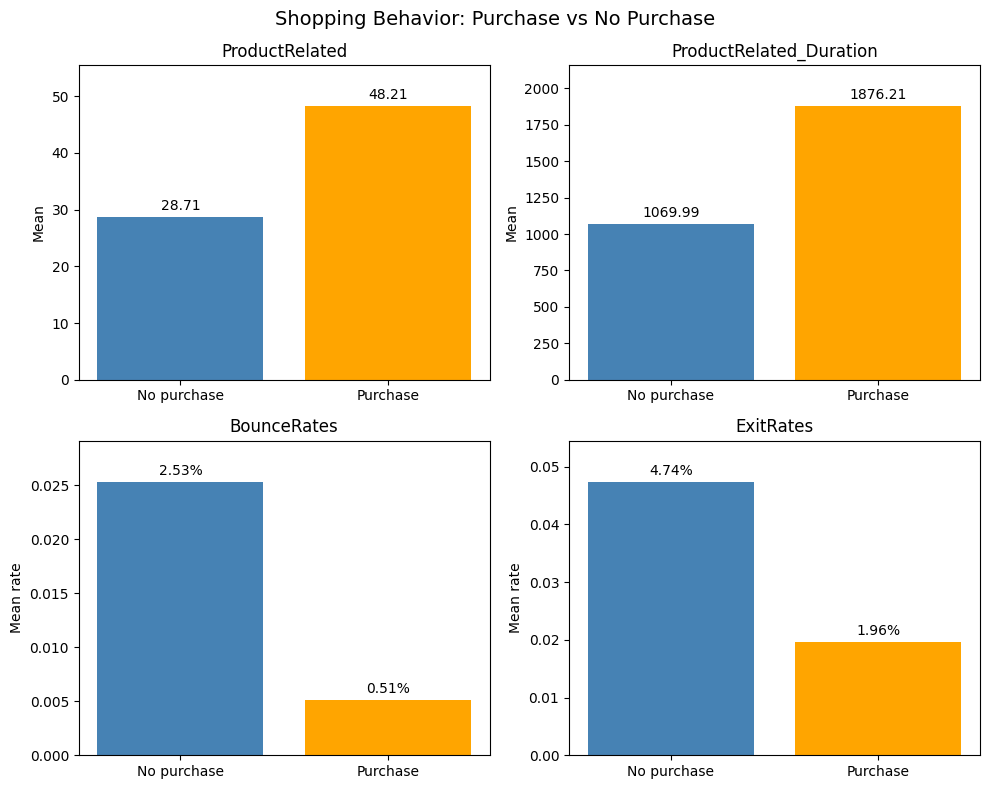

In [407]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates"
    ]
story_table = (df.groupby("Revenue")[story_features].mean().T)
story_table.columns = ["No purchase", "Purchase"]
display(story_table)


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, feature in zip(axes, story_features):
    values = story_table.loc[feature]
    bars = ax.bar(["No purchase", "Purchase"], values, color=["steelblue", "orange"])

    # BounceRate and ExitRate are easier to understand as percentages
    if feature in ["BounceRates", "ExitRates"]:
        labels = [f"{value:.2%}" for value in values]
        ax.set_ylabel("Mean rate")

    else:
        labels = [f"{value:.2f}" for value in values]
        ax.set_ylabel("Mean")

    ax.set_ylim(top=values.max() * 1.15)
    ax.bar_label(bars, labels=labels, padding=3)
    ax.set_title(feature)


fig.suptitle("Shopping Behavior: Purchase vs No Purchase", fontsize=14)

plt.tight_layout()
plt.show()

### Dataset first exploration

We compared sessions that resulted in a purchase with sessions that did not.  
The clearest difference is that purchasing sessions show much stronger engagement with product pages. On average, they viewed about 48 product-related pages, compared to about 29 pages for non-purchasing sessions. They also spent much more time on these pages: around 1,876 seconds, compared to 1,070 seconds.  
At the same time, purchasing sessions had much lower bounce and exit rates. The average bounce rate decreased from about 2.53% to 0.51%, while the exit rate decreased from 4.74% to 1.96%.  
Overall, the data suggests that sessions resulting in purchases are characterized by more product exploration, longer browsing time, and lower bounce and exit rates.

## 1.2

In [408]:
df["BrowserGroup"] = np.where(df["Browser"] == 13, "Browser 13", "Other browsers")
print(df["BrowserGroup"].value_counts())

BrowserGroup
Other browsers    12269
Browser 13           61
Name: count, dtype: int64


In [409]:
story_table = df.groupby("BrowserGroup").mean(numeric_only=True).T
story_table.columns = ["Other Browsers", "Browser 13"]
story_table

,Other Browsers,Browser 13
Administrative,1.754098,2.317956
Administrative_Duration,73.716530,80.853921
Informational,0.229508,0.504931
Informational_Duration,4.717486,34.620336
ProductRelated,14.885246,31.815225
ProductRelated_Duration,699.388395,1197.209080
BounceRates,0.034373,0.022131
ExitRates,0.052842,0.043024
PageValues,26.268249,5.787936
SpecialDay,0.000000,0.061733


,Other Browsers,Browser 13,Difference (%)
Informational_Duration,34.620336,4.717486,-86.373655
Informational,0.504931,0.229508,-54.546633
ProductRelated,31.815225,14.885246,-53.213451
ProductRelated_Duration,1197.209080,699.388395,-41.581767
Administrative,2.317956,1.754098,-24.325635
Administrative_Duration,80.853921,73.716530,-8.827514
ExitRates,0.043024,0.052842,22.820300
BounceRates,0.022131,0.034373,55.316528


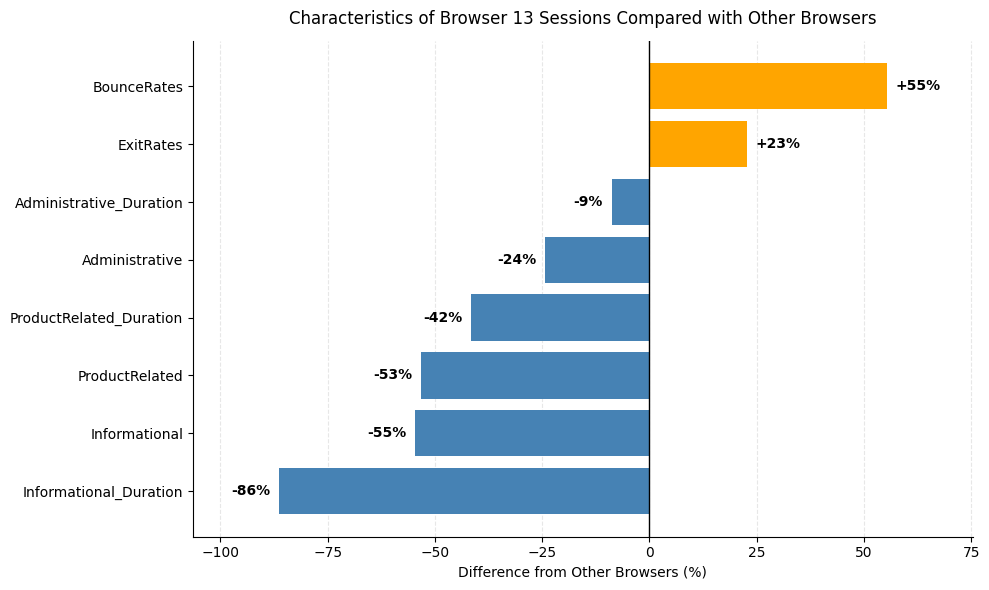

In [410]:
features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates"
    ]

browser13 = df[df["Browser"] == 13]
others = df[df["Browser"] != 13]

comparison_table = pd.DataFrame({
    "Other Browsers": others[features].mean(),
    "Browser 13": browser13[features].mean()
    })

# Percentage difference compared with other browsers
comparison_table["Difference (%)"] = (
    (comparison_table["Browser 13"]
     - comparison_table["Other Browsers"])
    / comparison_table["Other Browsers"]
) * 100

# Sort for easier interpretation
comparison_table = comparison_table.sort_values("Difference (%)")
display(comparison_table)


# -------------------------
# Visualization
# -------------------------

fig, ax = plt.subplots(figsize=(10, 6))

differences = comparison_table["Difference (%)"]

# Different colors:
# negative = Browser 13 lower
# positive = Browser 13 higher
colors = ["steelblue" if value < 0 else "orange" for value in differences]

bars = ax.barh(comparison_table.index, differences, color=colors)

# Zero reference line
ax.axvline(0, color="black", linewidth=1)

# Percentage labels
for bar, value in zip(bars, differences):

    y = bar.get_y() + bar.get_height() / 2

    if value >= 0:
        ax.text(
            value + 2,
            y,
            f"+{value:.0f}%",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )

    else:
        ax.text(
            value - 2,
            y,
            f"{value:.0f}%",
            va="center",
            ha="right",
            fontsize=10,
            fontweight="bold"
        )


# Give labels enough room
xmin = differences.min() - 20
xmax = differences.max() + 20

ax.set_xlim(xmin, xmax)
ax.set_xlabel("Difference from Other Browsers (%)")
ax.set_title("Characteristics of Browser 13 Sessions Compared with Other Browsers", pad=12)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light grid for readability
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Plot overview

This chart compares the average characteristics of Browser 13 sessions with those of all other browser sessions.  
Each bar shows the percentage difference between the Browser 13 mean and the mean for other browsers. Positive values mean Browser 13 is higher, while negative values mean Browser 13 is lower.

### Observations

Browser 13 sessions show much lower browsing engagement than sessions using other browsers.  
They visit fewer administrative pages (-24%), informational pages (-55%), and product-related pages (-53%). They also spend less time on these page types, especially on informational pages, where the average duration is about 86% lower. Product-related duration is also about 42% lower.  
At the same time, Browser 13 sessions have a 55% higher bounce rate and a 23% higher exit rate.  
Overall, this suggests that Browser 13 sessions tend to be shorter and involve less interaction with the website.

# Task 2

### Normalization

According to the documentation, before the clustering analysis, the data frame needs to be preprocessed.  
Numerical variables will be standardized using StandardScaler, while nominal variables will be one-hot encoded. Boolean variables will be turned into 0/1 values.

* Applying the log transformation to strongly right-skewed numerical features
* Applying the StandardScaler to numerical variables
* one-hot encoding for the nominal variables
* Boolean variables are turned into 0/1 values

In [411]:
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("online_shoppers_intention.csv")

# Separate the class label
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"]).copy()

# Convert binary variable
X["Weekend"] = X["Weekend"].astype(int)

# Define numerical features
numerical_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
    ]

# Strongly right-skewed numerical features
log_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "PageValues"
    ]

# Nominal categorical features
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
    ]

# Reduce skewness of strongly skewed numerical features
X[log_columns] = np.log1p(X[log_columns])

# Scale numerical features only
scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

# One-hot encode nominal features
# These remain 0/1 and are NOT standardized
X = pd.get_dummies(X, columns=categorical_columns, dtype=int)

# Keep the variable name used in the later tasks
X_scaled_cleaned = X.to_numpy(dtype=float)

# Make df.columns correspond to the preprocessed matrix
# so your later code works:
# pd.DataFrame(X_scaled_cleaned, columns=df.columns)
df = X.copy()

print("Original number of rows:", X.shape[0])
print("Number of features after preprocessing:", X.shape[1])

display(X.head().round(2))

Original number of rows: 12330
Number of features after preprocessing: 74


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.92,-0.98,-0.48,-0.46,-1.95,-2.92,3.67,3.23,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1
1,-0.92,-0.98,-0.48,-0.46,-1.59,-0.88,-0.46,1.17,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1
2,-0.92,-0.98,-0.48,-0.46,-1.95,-2.92,3.67,3.23,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1
3,-0.92,-0.98,-0.48,-0.46,-1.59,-2.28,0.57,1.99,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1
4,-0.92,-0.98,-0.48,-0.46,-0.43,0.24,-0.05,0.14,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1


# Task 3

## preparing the dataset

In [412]:
from sklearn.cluster import AffinityPropagation, DBSCAN, Birch
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# Prepare data
df_scaled_cleaned = pd.DataFrame(X_scaled_cleaned, columns=df.columns)

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

SAMPLE_SIZE = int(len(df_scaled_cleaned) * 0.1)
RANDOM_STATE = 42

# Reconstruct VisitorType for stratification
strata = df_scaled_cleaned[
    [
        "VisitorType_New_Visitor",
        "VisitorType_Other",
        "VisitorType_Returning_Visitor"
    ]
].idxmax(axis=1)

# Create AP sample
df_sample, _ = train_test_split(
    df_scaled_cleaned,
    train_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=strata
)

# PCA for clustering - retain 80% of variance. 
pca = PCA(n_components=0.8)

# Transform the df sample using PCA 
X_cluster = pca.fit_transform(df_sample)

print("PCA components:", pca.n_components_)
print("Variance retained:", pca.explained_variance_ratio_.sum())

PCA components: 10
Variance retained: 0.8033637099936918


Dimensionality reduction is performed to prevent the "curse of dimensionality". 10 Principle components are retained (0.8 = 80% of variance).

## 3.1 Affinity Propagation Clustering

It measures similarity between observations and iteratively selects some actual observations as exemplars.  
Other observations are assigned to those representatives. The preference parameter strongly affects the numberof  exemplars, and therefore how many clusters are created.

In [413]:
AP_PREFERENCE = -1000

affinity_model = AffinityPropagation(
    damping=0.9,
    preference=AP_PREFERENCE,
    max_iter=300,
    convergence_iter=15,
    random_state=RANDOM_STATE)

labels_ap = affinity_model.fit_predict(X_cluster)

n_clusters_ap = len(np.unique(labels_ap))

print("Affinity Propagation")
print("Preference:", AP_PREFERENCE)
print("Number of clusters:", n_clusters_ap)

print(pd.Series(labels_ap).value_counts().sort_index())

Affinity Propagation
Preference: -1000
Number of clusters: 5
0    207
1     77
2     91
3    432
4    426
Name: count, dtype: int64


In [429]:
preferences = np.arange(-1000, -500, 50)

for preference in preferences:

    model = AffinityPropagation(
        damping=0.9,
        preference=preference,
        max_iter=500,
        convergence_iter=20,
        random_state=RANDOM_STATE
    )

    labels = model.fit_predict(X_cluster)

    counts = pd.Series(labels).value_counts().sort_index()

    print(
        f"preference={preference:4d} | "
        f"clusters={len(counts)} | "
        f"sizes={sorted(counts.tolist(), reverse=True)}"
    )

preference=-1000 | clusters=5 | sizes=[432, 426, 207, 91, 77]
preference=-950 | clusters=6 | sizes=[389, 321, 207, 151, 89, 76]
preference=-900 | clusters=6 | sizes=[383, 327, 209, 148, 89, 77]
preference=-850 | clusters=6 | sizes=[383, 327, 209, 148, 89, 77]
preference=-800 | clusters=6 | sizes=[383, 327, 209, 148, 89, 77]
preference=-750 | clusters=6 | sizes=[383, 327, 209, 148, 89, 77]
preference=-700 | clusters=6 | sizes=[383, 327, 209, 148, 89, 77]
preference=-650 | clusters=6 | sizes=[383, 327, 209, 148, 89, 77]
preference=-600 | clusters=6 | sizes=[382, 328, 210, 148, 91, 74]
preference=-550 | clusters=6 | sizes=[382, 328, 210, 148, 91, 74]


## 3.2: DBSCAN Clustering

In [415]:
MIN_SAMPLES = 10

# Find distance to the 10th nearest neighbour
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors.fit(X_cluster)
distances, _ = neighbors.kneighbors(X_cluster)
k_distances = np.sort(distances[:, -1])

DBSCAN_EPS = 1.5
dbscan_model = DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan_model.fit_predict(X_cluster)

n_clusters_dbscan = len(set(labels_dbscan) - {-1})

n_noise = np.sum(labels_dbscan == -1)

print("Number of clusters:", n_clusters_dbscan)
print("Number of noise points:", n_noise)

print(pd.Series(labels_dbscan).value_counts().sort_index())

Number of clusters: 4
Number of noise points: 295
-1    295
 0    814
 1     60
 2     56
 3      8
Name: count, dtype: int64


Number of clusters: 1
Number of noise points: 0
0    1233
Name: count, dtype: int64


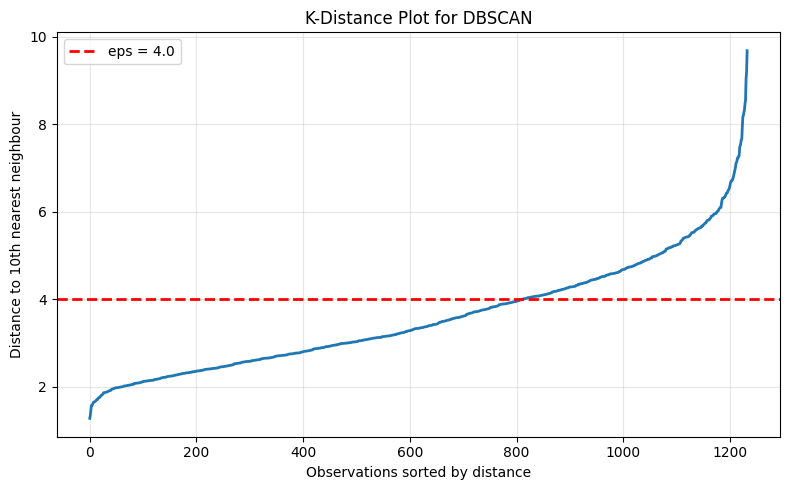

In [480]:
MIN_SAMPLES = 10

# 2. DBSCAN parameters
DBSCAN_EPS = 4.0

dbscan_model = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=MIN_SAMPLES
)

labels_dbscan = dbscan_model.fit_predict(X_cluster)

#3. Calculate clustering results

n_clusters_dbscan = len(set(labels_dbscan) - {-1})
n_noise = np.sum(labels_dbscan == -1)

print("Number of clusters:", n_clusters_dbscan)
print("Number of noise points:", n_noise)

print(
    pd.Series(labels_dbscan)
    .value_counts()
    .sort_index()
)

# 4. K-distance plot
plt.figure(figsize=(8, 5))

plt.plot(k_distances,linewidth=2)

# Show the DBSCAN eps value
plt.axhline(
    y=DBSCAN_EPS,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"eps = {DBSCAN_EPS}")

plt.xlabel("Observations sorted by distance")

plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbour")

plt.title("K-Distance Plot for DBSCAN")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### How to choose the `eps` parameter

I chose eps near the elbow because the elbow approximately marks the transition from relatively dense regions to much sparser regions in the data.(The graph looks like `eps`=1.5~2.0 is the sweet spot)\
The case of `eps`=2.5 has few noise data and the scores on task 4 is the best.
That's why I chose the `eps`=2.5.

In [441]:
# step 2: choose eps values based on the k-distance plot and evaluate clustering results
eps_values = [
    1.0,
    1.5,
    1.75,
    2.0
]

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = model.fit_predict(X_cluster)

    n_clusters = len(set(labels) - {-1})
    noise_ratio = np.mean(labels == -1)

    print(f"eps={eps:.2f} | clusters={n_clusters} | noise={noise_ratio * 100:.1f}%")

eps=1.00 | clusters=8 | noise=60.3%
eps=1.50 | clusters=4 | noise=23.9%
eps=1.75 | clusters=2 | noise=11.6%
eps=2.00 | clusters=1 | noise=4.0%


In [ ]:
# Step 3: choose eps based on the analysis
DBSCAN_EPS = 1.5

dbscan_model = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=MIN_SAMPLES
)

labels_dbscan_example = dbscan_model.fit_predict(
    X_cluster
)

## 3.3: BIRCH Clustering

In [446]:
BIRCH_N_CLUSTERS = 4

birch_model = Birch(n_clusters=BIRCH_N_CLUSTERS)
labels_birch = birch_model.fit_predict(X_cluster)

n_clusters_birch = len(np.unique(labels_birch))

print("Birch")
print("Number of clusters:", n_clusters_birch)

print(pd.Series(labels_birch).value_counts().sort_index())

Birch
Number of clusters: 4
0    805
1    230
2     96
3    102
Name: count, dtype: int64


### Visualization

PCA is also used for visualization.  
The first two principal components explain about 44% of the variance, so the two-dimensional plots do not show all of the cluster structure used by the algorithms.

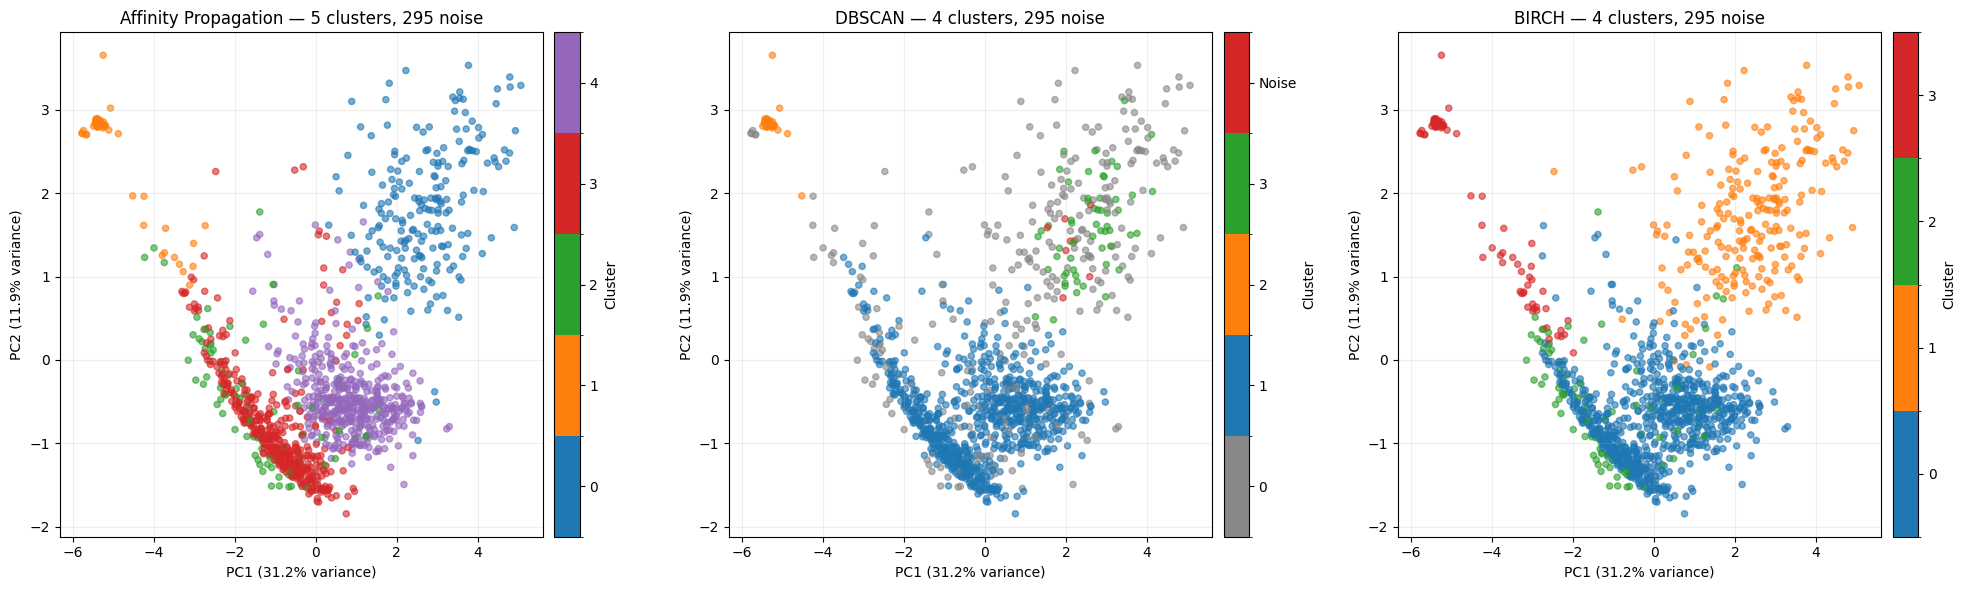

In [447]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

results = [
    ("Affinity Propagation", labels_ap),
    ("DBSCAN", labels_dbscan),
    ("BIRCH", labels_birch)]

pc1_ratio = pca.explained_variance_ratio_[0] * 100
pc2_ratio = pca.explained_variance_ratio_[1] * 100

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, labels) in zip(axes, results):

    unique_labels = sorted(np.unique(labels))
    n_clusters = len(set(labels) - {-1})

    # Convert cluster IDs to consecutive integers
    # for visualization
    label_map = {label: i for i, label in enumerate(unique_labels)}
    plot_labels = np.array([label_map[label] for label in labels])

    # One color per category; noise is a separate gray category.
    cluster_labels = [label for label in unique_labels if label != -1]
    palette_name = "tab10" if len(cluster_labels) <= 10 else "tab20"
    palette = plt.get_cmap(palette_name)
    if len(cluster_labels) > 20:
        palette = plt.get_cmap("hsv", len(cluster_labels))
    cluster_colors = {label: palette(j) for j, label in enumerate(cluster_labels)}
    colors = ["#888888" if label == -1 else cluster_colors[label]
              for label in unique_labels]
    cmap = ListedColormap(colors)
    boundaries = np.arange(len(unique_labels) + 1) - 0.5
    norm = BoundaryNorm(boundaries, cmap.N)

    scatter = ax.scatter(
        X_cluster[:, 0],
        X_cluster[:, 1],
        c=plot_labels,
        cmap=cmap,
        norm=norm,
        s=20,
        alpha=0.6)
    # Axis labels
    ax.set_xlabel(f"PC1 ({pc1_ratio:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pc2_ratio:.1f}% variance)")
    # Title
    if n_noise > 0:
        ax.set_title(f"{name} — {n_clusters} clusters, {n_noise} noise")
    else:
        ax.set_title(f"{name} — {n_clusters} clusters")

    ax.grid(alpha=0.2)

    # Colorbar
    if len(cluster_labels) <= 15:
        colorbar = fig.colorbar(
            ScalarMappable(norm=norm, cmap=cmap),
            ax=ax,
            ticks=range(len(cluster_labels) + (1 if n_noise > 0 else 0)),
            pad=0.02)
        # Create colorbar labels
        colorbar_labels = [str(label) for label in cluster_labels]
        if n_noise > 0:
            colorbar_labels.append("Noise")
        colorbar.set_label("Cluster")
        colorbar.set_ticklabels(colorbar_labels)


plt.tight_layout()
plt.show()

### Observations

The clustering was performed in the top 10 principal components, and the top 2 principal components was used for visualization. PC1 and PC2 explain about 31.2% and 11.9% of the variance respectively, so the 2D figures display about 43.1% of the total variance.

| Method | Parameter to focus on | How to choose it | What to check |
|---|---|---|---|
| **Affinity Propagation** | `preference` | Try several values | Silhouette ↑, DB ↓, CH ↑, sensible cluster count |
| **DBSCAN** | `eps` first; keep `min_samples=5` initially | Use the 5-distance plot to find the elbow, then test values around it | Metrics + number of clusters + noise % |
| **BIRCH** | `n_clusters` | Try 2–10 clusters | Silhouette ↑, DB ↓, CH ↑ |

### why adjust some of parameters, not all parameters?
| Method | Parameter | What to say |
|---|---|---|
| AP | `preference` | Tuned because it strongly affects number of exemplars/clusters |
| AP | `damping=0.9` | Fixed to provide stable convergence |
| DBSCAN | `min_samples=5` | Fixed as a baseline density requirement |
| DBSCAN | `eps` | Tuned using the 5-distance plot |
| BIRCH | `n_clusters` | Tuned because it determines final cluster count |
| BIRCH | `threshold=0.5` | Kept at default to limit the number of parameters being tuned |
| BIRCH | `branching_factor=50` | Kept at default because it mainly controls CF-tree structure/efficiency |

# Task 4

## 4.1: Silhouette Score

### What is the Silhouette Score?

The silhouette score is a measure of clustering quality for k-cluster methods independent of $k$.

For one observation $o$:

Let $a(o)$ be the average distance from $o$ to points in its own cluster,
$$ 
\begin{aligned}
a(o)&=\frac{\sum_{o'\in C_i,o\neq o'}dist(o,o')}{|C_j|-1} \quad (o \in C_i(1\leq i \leq k))
\end{aligned}
$$
and
let $b(o)$ be the smallest average distance from $o$ to any other cluster
$$
\begin{aligned}
b(o)=min_{C_j:1\leq j \leq k, i\neq j}\frac{\sum_{o'\in C_j}dist(o,o')}{|C_j|}

\end{aligned}
$$
Then let $C_I$ be the cluster to which one observvation $o$ belongs,
$$
\begin{aligned}
s(o)=
\begin{cases}
\frac{b(o)-a(o)}
{\max(a(o),b(o))} & (|C_I|>1)\\
0 & (|C_I|=1)
\end{cases}
\end{aligned}
$$

The final Silhouette score is the average of $s(o)$ over all observations.

Interpretation:
- $s_C > 0.7$: strong cluster structure
- $s_C > 0.5$: reasonable cluster structure
- $s_C > 0.25$: weak cluster structure
- $s_C < 0.25$: no cluster structure

The higher the value $s_C$ is, the better the clustering is.


In [421]:
def euclidean_distance(point1, point2):
    total = 0.0
    for x, y in zip(point1, point2):
        total += (x - y) * (x - y)
    return np.sqrt(total)


def remove_noise(X, labels):
    X_eval = []
    labels_eval = []
    for i in range(len(labels)):
        if labels[i] != -1:
            X_eval.append(X[i])
            labels_eval.append(labels[i])
    return X_eval, labels_eval


def manual_silhouette_score(X, labels):

    # Remove DBSCAN noise
    X_eval, labels_eval = remove_noise(X, labels)
    # Find clusters once
    clusters = {}
    for i in range(len(labels_eval)):
        cluster = labels_eval[i]
        if cluster not in clusters:
            clusters[cluster] = []
        clusters[cluster].append(i)
    # Need at least 2 clusters
    if len(clusters) < 2:
        return float("nan")
    silhouette_values = []
    # Calculate silhouette for every point
    for i in range(len(X_eval)):
        current_cluster = labels_eval[i]
        same_cluster = clusters[current_cluster]
        # Single-point cluster
        if len(same_cluster) == 1:
            silhouette_values.append(0.0)
            continue
        # a(i): average distance to points in own cluster
        total_distance = 0.0
        for j in same_cluster:
            if j != i:
                total_distance += euclidean_distance(X_eval[i], X_eval[j])
        a_i = total_distance / (len(same_cluster) - 1)
        # b(i): smallest average distance to another cluster
        b_i = float("inf")
        for cluster, indices in clusters.items():
            if cluster == current_cluster:
                continue
            total_distance = 0.0
            for j in indices:
                total_distance += euclidean_distance(X_eval[i],X_eval[j])
            average_distance = total_distance / len(indices)
            if average_distance < b_i:
                b_i = average_distance
        # Silhouette
        denominator = max(a_i, b_i)
        if denominator == 0:
            s_i = 0.0
        else:
            s_i = (b_i - a_i) / denominator
        silhouette_values.append(s_i)
    return sum(silhouette_values) / len(silhouette_values)

In [422]:
silhouette_ap = manual_silhouette_score(X_cluster, labels_ap)
print("Affinity Propagation:", silhouette_ap)

Affinity Propagation: 0.2725010425768826


In [423]:
silhouette_dbscan = manual_silhouette_score(X_cluster, labels_dbscan)
print("DBSCAN:", silhouette_dbscan)

DBSCAN: 0.2706630047205609


In [424]:
silhouette_birch = manual_silhouette_score(X_cluster, labels_birch)
print("Birch:", silhouette_birch)

Birch: 0.26056367057681207


## 4.2: Davies Bouldin Score
The lower the score is, the better the clusters are.  
A smaller Davies–Bouldin means that clusters are more compact and better separated.

In [425]:
from sklearn.metrics import davies_bouldin_score


def evaluate_davies_bouldin(X, labels):
    """
    Calculate the Calinski-Harabasz Index for a clustering result.

    Parameters:
        X      : Data points used for clustering
        labels : Cluster labels assigned to each data point

    Returns:
        Calinski-Harabasz Index
    """
    #Eclude DBSCAN noise
    X_eval, labels_eval = remove_noise(X, labels)

    if len(np.unique(labels_eval)) < 2:
        return np.nan

    return davies_bouldin_score(X_eval, labels_eval)


db_ap = evaluate_davies_bouldin(X_cluster, labels_ap)
print("Affinity Propagation:", db_ap)
db_dbscan = evaluate_davies_bouldin(X_cluster, labels_dbscan)
print("DBSCAN:", db_dbscan)
db_birch = evaluate_davies_bouldin(X_cluster, labels_birch)
print("Birch:", db_birch)

Affinity Propagation: 1.2407092432871252
DBSCAN: 0.9061356288827673
Birch: 1.2274053124374678


## 4.3: Calinski-Harabasz Index 

In [426]:
from sklearn.metrics import calinski_harabasz_score


def evaluate_calinski_harabasz(X, labels):
    """
    Calculate the Calinski-Harabasz Index for a clustering result.

    Parameters:
        X      : Data points used for clustering
        labels : Cluster labels assigned to each data point

    Returns:
        Calinski-Harabasz Index
    """
    # Remove DBSCAN noise
    X_eval, labels_eval = remove_noise(X, labels)

    if len(np.unique(labels_eval)) < 2:
        return np.nan

    return calinski_harabasz_score(X_eval, labels_eval)

ch_ap = evaluate_calinski_harabasz(X_cluster, labels_ap)
print("Affinity Propagation:", ch_ap)
ch_dbscan = evaluate_calinski_harabasz(X_cluster, labels_dbscan)
print("DBSCAN:", ch_dbscan)
ch_birch = evaluate_calinski_harabasz(X_cluster, labels_birch)
print("Birch:", ch_birch)

Affinity Propagation: 410.7256834042785
DBSCAN: 197.3983127794329
Birch: 381.0266963549962


### compare the different algorithm parameter choices in terms of three scores such as Silhouette score, Davies Bouldin Score, Calinski-Harabasz Index

In [96]:
results_ap_row = []

for ap_prefrence in [-5000, -4000, -3000, -2000, -1000, -500]:
    affinity_model = AffinityPropagation(
        damping=0.9,
        preference=ap_prefrence,
        max_iter=300,
        convergence_iter=15,
        random_state=RANDOM_STATE)

    labels_ap = affinity_model.fit_predict(X_cluster)

    n_clusters_ap = len(np.unique(labels_ap))

    silhouette_ap = manual_silhouette_score(X_cluster, labels_ap)
    db_ap = evaluate_davies_bouldin(X_cluster, labels_ap)
    ch_ap = evaluate_calinski_harabasz(X_cluster, labels_ap)

    results_ap_row.append({
        "Preference": ap_prefrence,
        "Clusters": n_clusters_ap,
        "Silhouette": silhouette_ap,
        "Davies-Bouldin": db_ap,
        "Calinski-Harabasz": ch_ap
    })

result_ap=pd.DataFrame(results_ap_row, columns=["Preference", "Clusters", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz"])
display(result_ap)

,Preference,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,-5000,1,NaN,NaN,NaN
1,-4000,2,0.224737,1.661669,388.993290
2,-3000,3,0.255470,1.435849,376.182158
3,-2000,3,0.216396,1.549960,349.472375
4,-1000,5,0.272501,1.240709,410.725683
5,-500,7,0.230162,1.286106,369.936595


In [443]:
MIN_SAMPLES = 10
results_dbscan_rows = []
for eps in [1.0, 1.5, 1.75, 2.0]:
    dbscan_model = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels_dbscan = dbscan_model.fit_predict(X_cluster)

    n_clusters_dbscan = len(set(labels_dbscan) - {-1})

    silhouette_dbscan = manual_silhouette_score(X_cluster, labels_dbscan)
    db_dbscan = evaluate_davies_bouldin(X_cluster, labels_dbscan)
    ch_dbscan = evaluate_calinski_harabasz(X_cluster, labels_dbscan)

    results_dbscan_rows.append({
        "eps": eps,
        "Clusters": n_clusters_dbscan,
        "Silhouette": silhouette_dbscan,
        "Davies-Bouldin": db_dbscan,
        "Calinski-Harabasz": ch_dbscan
    })

results_dbscan = pd.DataFrame(
    results_dbscan_rows,
    columns=["eps", "Clusters", "Silhouette",
             "Davies-Bouldin", "Calinski-Harabasz"]
    )
display(results_dbscan)

,eps,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,1.00,8,0.241390,1.221472,234.646213
1,1.50,4,0.270663,0.906136,197.398313
2,1.75,2,0.046091,1.317080,8.298968
3,2.00,1,NaN,NaN,NaN


In [439]:
results_birch_row = []
for n_clusters in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
    birch_model = Birch(n_clusters=n_clusters)
    labels_birch = birch_model.fit_predict(X_cluster)

    silhouette_birch = manual_silhouette_score(X_cluster, labels_birch)
    db_birch = evaluate_davies_bouldin(X_cluster, labels_birch)
    ch_birch = evaluate_calinski_harabasz(X_cluster, labels_birch)

    results_birch_row.append({
        "n_clusters": n_clusters,
        "Silhouette": silhouette_birch,
        "Davies-Bouldin": db_birch,
        "Calinski-Harabasz": ch_birch
    })

result_birch = pd.DataFrame(results_birch_row, columns=["n_clusters", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz"])
display(result_birch)

,n_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.258073,1.396805,303.369362
1,3,0.272926,1.502358,339.589898
2,4,0.294873,1.203475,359.678830
3,5,0.245722,1.286265,385.355123
4,6,0.260564,1.227405,381.026696
5,7,0.255194,1.398033,347.146713
6,8,0.225288,1.458661,315.554332
7,9,0.227081,1.510025,291.623471
8,10,0.226945,1.553449,271.421198


# Task 5

## 5.1: Euclidean distance + DBSCAN

The Euclidean distance function was manually implemented in task 4.1.  
Since the function does not use any predefined distance functions or libraries, we reuse the same implementation here as the distance metric for DBSCAN.

Data used for clustering: (1233, 10)
Data used for clustering: (1233, 10)
Original data: (1233, 10)
PCA data: (1233, 10)


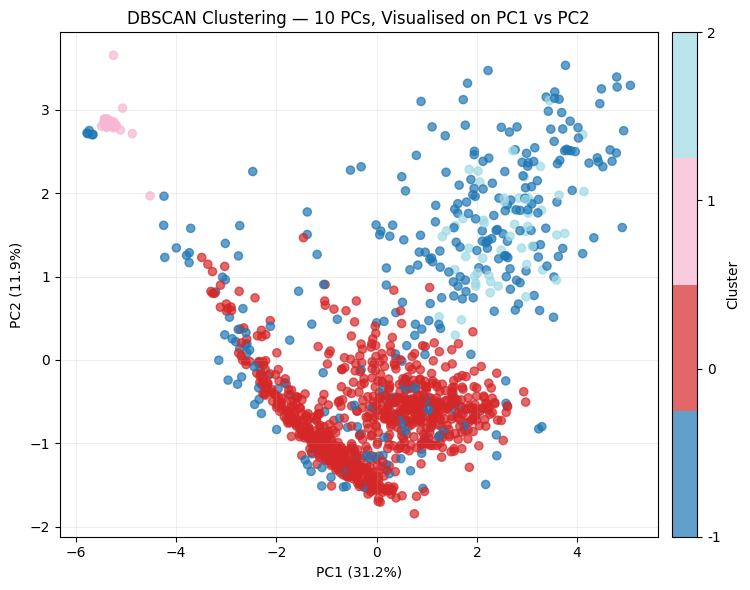

(1233, 10)

In [463]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

print("Data used for clustering:", X_cluster.shape)

print("Data used for clustering:", X_cluster.shape)
# 1. DBSCAN clustering in 10-dimensional PC space

print("Original data:", X_cluster.shape)
print("PCA data:", X_cluster.shape)

dbscan = DBSCAN(
    eps=1.6,
    min_samples=15,
    metric=euclidean_distance)

labels_euclidean = dbscan.fit_predict(X_cluster)

unique_labels = np.unique(labels_euclidean)

#2. Visualise the clusters using PC1 and PC2
fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("tab20", max(len(unique_labels), 1))

scatter = ax.scatter(
    X_cluster[:, 0],              # PC1 — visualisation only
    X_cluster[:, 1],              # PC2 — visualisation only
    c=labels_euclidean,       # labels based on all 10 PCs
    cmap=cmap,
    alpha=0.7,
    s=35)

#3. Colourbar
colorbar = fig.colorbar(scatter,ax=ax,ticks=unique_labels,pad=0.02)
colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)

# 4. Axis labels
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("DBSCAN Clustering — 10 PCs, Visualised on PC1 vs PC2")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()
X_cluster.shape

Data used for k-distance curve: (1233, 10)


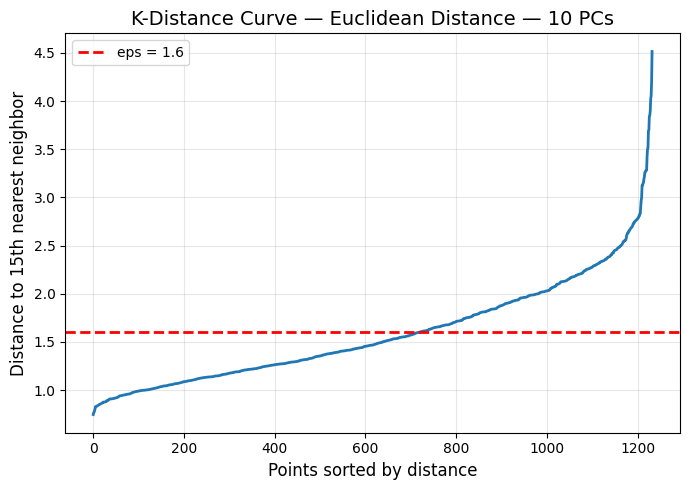

In [464]:
MIN_SAMPLES = 15

print("Data used for k-distance curve:", X_cluster.shape)

# 1. Nearest-neighbor model using Euclidean distance
neighbors = NearestNeighbors(
    n_neighbors=MIN_SAMPLES,
    metric="euclidean")

neighbors.fit(X_cluster)

distances, _ = neighbors.kneighbors(X_cluster)

k_distances = distances[:, -1]
k_distances = np.sort(k_distances)

# 3. Plot
plt.figure(figsize=(7, 5))

plt.plot(
    k_distances,
    linewidth=2)

plt.axhline(
    y=1.6,
    color="red",
    linestyle="--",
    linewidth=2,
    label="eps = 1.6")

plt.xlabel("Points sorted by distance",fontsize=12)
plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbor",fontsize=12)
plt.title("K-Distance Curve — Euclidean Distance — 10 PCs",fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


## 5.2: Manhattan distance + DBSCAN

Data used for clustering: (1233, 10)


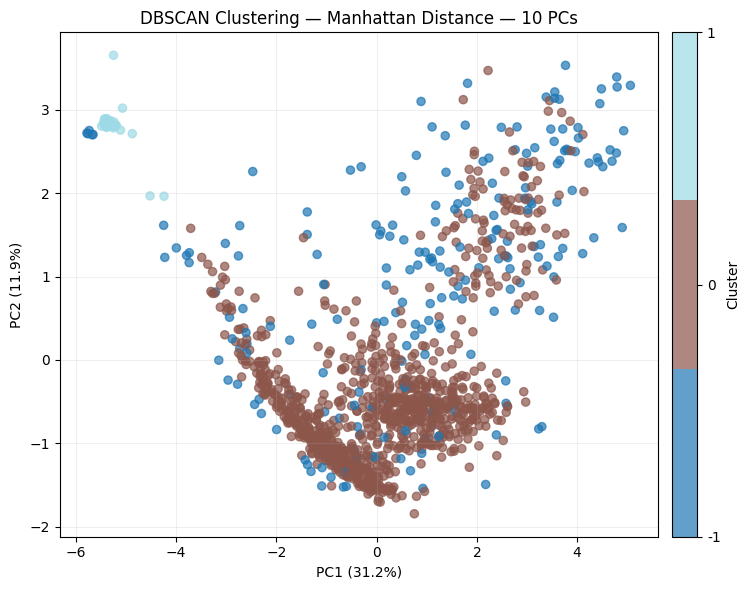

Number of clusters: 2
Number of noise points: 295
-1    213
 0    959
 1     61
Name: count, dtype: int64


In [477]:
print("Data used for clustering:", X_cluster.shape)

# 1. Manhattan distance function
def manhattan_distance(point1, point2):
    assert len(point1) == len(point2)
    distance = 0
    for x1, x2 in zip(point1, point2):
        distance += abs(x1 - x2)
    return distance

# 2. DBSCAN clustering using ALL 10 PCs
dbscan = DBSCAN(
    eps=4,
    min_samples=12,
    metric=manhattan_distance)

labels_manhattan = dbscan.fit_predict(X_cluster)
n_clusters_manhattan = len(set(labels_manhattan) - {-1})
unique_labels = np.unique(labels_manhattan)
# 3. Visualise clusters using PC1 vs PC2 only
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.get_cmap(
    "tab20",
    max(len(unique_labels), 1))
scatter = ax.scatter(
    X_cluster[:, 0],       # PC1 — visualisation only
    X_cluster[:, 1],       # PC2 — visualisation only
    c=labels_manhattan,
    cmap=cmap,
    alpha=0.7,
    s=35)

# 4. Colourbar
colorbar = fig.colorbar(
    scatter,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)

# 6. Axis labels
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")

ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

ax.set_title("DBSCAN Clustering — Manhattan Distance — 10 PCs")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()
print("Number of clusters:", n_clusters_manhattan)
print("Number of noise points:", n_noise)

print(
    pd.Series(labels_manhattan)
    .value_counts()
    .sort_index()
)

Data used for k-distance curve: (1233, 10)


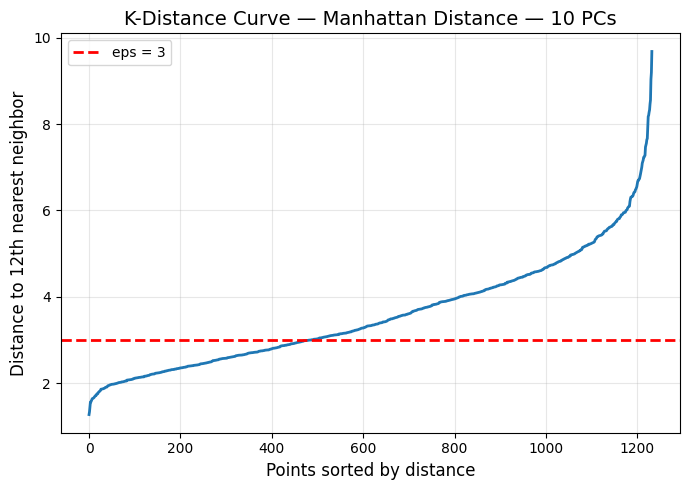

Number of clusters: 4
Number of noise points: 295
-1    295
 0    814
 1     60
 2     56
 3      8
Name: count, dtype: int64


In [476]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 12

print("Data used for k-distance curve:", X_cluster.shape)
#1. Nearest-neighbor model using Manhattan distance
neighbors = NearestNeighbors(
    n_neighbors=MIN_SAMPLES,
    metric="manhattan")

neighbors.fit(X_cluster)

# Calculate nearest-neighbour distances
distances, _ = neighbors.kneighbors(X_cluster)

# Distance to the 12th nearest neighbour
k_distances = distances[:, -1]

# Sort distances
k_distances = np.sort(k_distances)

# 2. Plot
plt.figure(figsize=(7, 5))

plt.plot(k_distances,linewidth=2)

# Current DBSCAN eps
plt.axhline(y=3,color="red",linestyle="--",linewidth=2,label="eps = 3")

# Keep text sizes fixed
plt.xlabel("Points sorted by distance",fontsize=12)

plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbor",fontsize=12)

plt.title("K-Distance Curve — Manhattan Distance — 10 PCs",fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print("Number of clusters:", n_clusters_dbscan)
print("Number of noise points:", n_noise)

print(
    pd.Series(labels_dbscan)
    .value_counts()
    .sort_index()
)

## 5.3: Cosine similarity distance + DBSCAN

In [467]:
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.cluster import DBSCAN


# 2. Cosine distance function
def cosine_distance(point1, point2):
    dot_product = 0
    magnitude1 = 0
    magnitude2 = 0

    for x1, x2 in zip(point1, point2):
        dot_product += x1 * x2
        magnitude1 += x1 * x1
        magnitude2 += x2 * x2

    magnitude1 = np.sqrt(magnitude1)
    magnitude2 = np.sqrt(magnitude2)

    if magnitude1 == 0 or magnitude2 == 0:
        return 0

    cosine_similarity = dot_product / (magnitude1 * magnitude2)

    return 1 - cosine_similarity

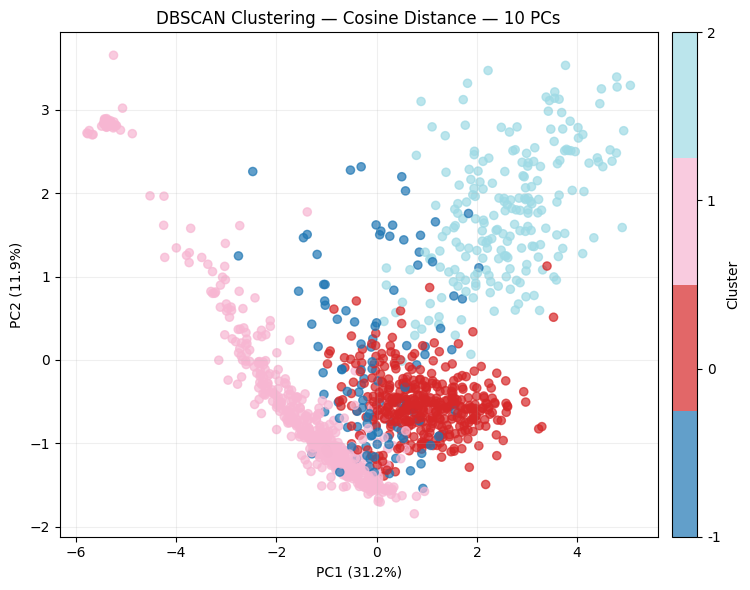

Number of clusters: 3
Number of noise points: 295
-1    109
 0    393
 1    521
 2    210
Name: count, dtype: int64


In [478]:
dbscan = DBSCAN(eps=0.06, min_samples=5, metric=cosine_distance)

# 3. DBSCAN clustering using ALL 10 PCs
dbscan = DBSCAN(
    eps=0.15,
    min_samples=15,
    metric=cosine_distance)

labels_cosine = dbscan.fit_predict(X_cluster)

unique_labels = np.unique(labels_cosine)
n_clusters_cosine = len(set(labels_cosine) - {-1})

# 4. Visualise clusters using PC1 vs PC2 only
fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("tab20",max(len(unique_labels), 1))

scatter = ax.scatter(
    X_cluster[:, 0],       # PC1
    X_cluster[:, 1],       # PC2
    c=labels_cosine,   # labels from all 10 PCs
    cmap=cmap,
    alpha=0.7,
    s=35)

# 5. Colourbar
colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)

# 6. Axis labels
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("DBSCAN Clustering — Cosine Distance — 10 PCs")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()
print("Number of clusters:", n_clusters_cosine)
print("Number of noise points:", n_noise)

print(
    pd.Series(labels_cosine)
    .value_counts()
    .sort_index()
)


Data used for k-distance curve: (1233, 10)


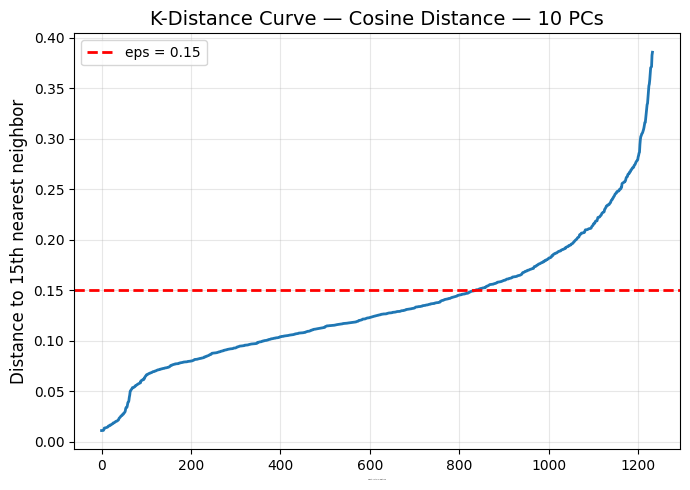

Number of clusters: 4
Number of noise points: 295
-1    295
 0    814
 1     60
 2     56
 3      8
Name: count, dtype: int64


In [474]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


MIN_SAMPLES = 15

print("Data used for k-distance curve:", X_cluster.shape)

# 1. Nearest-neighbor model using cosine distance
neighbors = NearestNeighbors(
    n_neighbors=MIN_SAMPLES,
    metric="cosine")

neighbors.fit(X_cluster)

# Calculate distances to nearest neighbours
distances, _ = neighbors.kneighbors(X_cluster)

# Distance to the 15th nearest neighbour
k_distances = distances[:, -1]

# Sort distances
k_distances = np.sort(k_distances)

# 3. Plot
plt.figure(figsize=(7, 5))

plt.plot(k_distances,linewidth=2)

# Current DBSCAN eps
plt.axhline(
    y=0.15,
    color="red",
    linestyle="--",
    linewidth=2,
    label="eps = 0.15"
)

plt.xlabel("Points sorted by distance",fontsize=1)
plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbor",fontsize=12)
plt.title("K-Distance Curve — Cosine Distance — 10 PCs",fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()
print("Number of clusters:", n_clusters_dbscan)
print("Number of noise points:", n_noise)

print(
    pd.Series(labels_dbscan)
    .value_counts()
    .sort_index()
)

## 5.4: Evaluate different distance functions


We use the same way to choose `eps` as task 3.2.

In [471]:
# Calculate silhouette values for each distance function
from numpy import iterable

score_euclidean = manual_silhouette_score(X_cluster, labels_euclidean)
score_manhattan = manual_silhouette_score(X_cluster, labels_manhattan)
score_cosine = manual_silhouette_score(X_cluster, labels_cosine)

# Print the results
print("Euclidean silhouette score:", score_euclidean.round(4))
print("Manhattan silhouette score:", score_manhattan.round(4))
print("Cosine silhouette score:", score_cosine.round(4))

Euclidean silhouette score: 0.3114
Manhattan silhouette score: 0.4903
Cosine silhouette score: 0.2344


### Silhouette interpretation:

s > 0.7: strong cluster structure  
s > 0.5: reasonable cluster structure  
s > 0.25: weak cluster structure  
s < 0.25: no cluster structure

### Visualisation of the different silhouette scores

Metric: euclidean


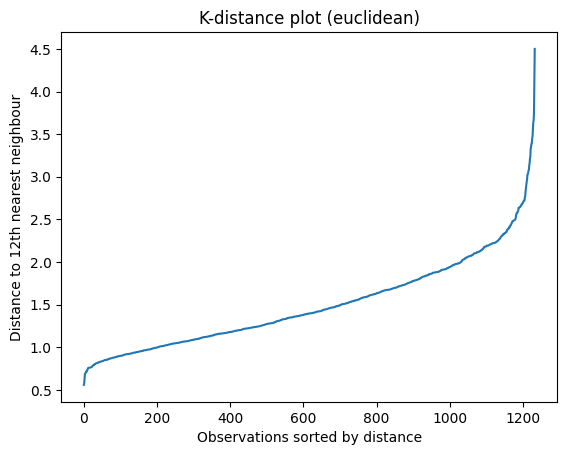

Metric: manhattan


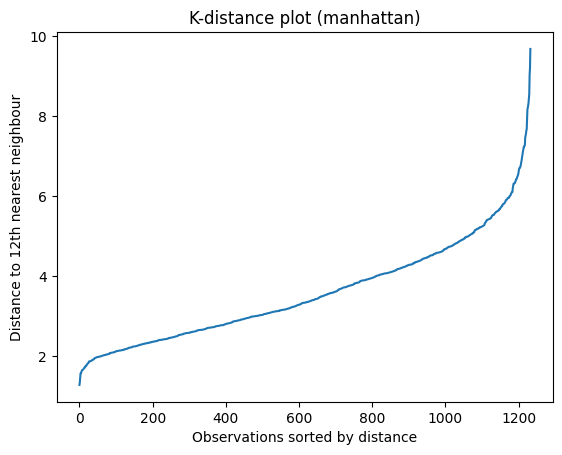

Metric: cosine


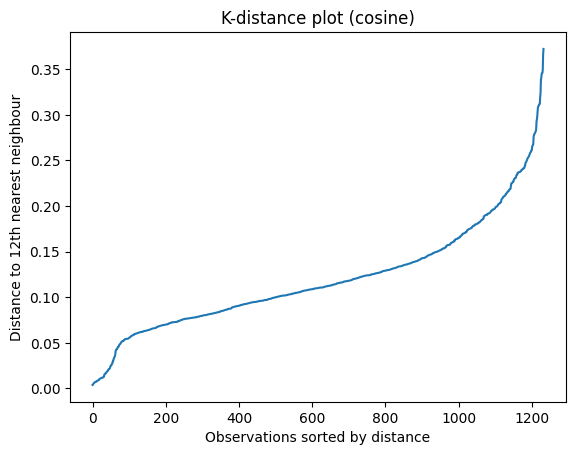

In [433]:
# Step 1: create k-distance plot
MIN_SAMPLES = 12

metrics = {"euclidean": euclidean_distance, "manhattan": manhattan_distance, "cosine": cosine_distance}

for metric_name, metric in metrics.items():
    print(f"Metric: {metric_name}")
    neighbors = NearestNeighbors(
        n_neighbors=MIN_SAMPLES,
        metric=metric,
        algorithm="brute"
    )

    neighbors.fit(X_cluster)

    distances, _ = neighbors.kneighbors(X_cluster)

    k_distances = np.sort(
        distances[:, -1]
    )

    plt.plot(k_distances)
    plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbour")
    plt.xlabel("Observations sorted by distance")
    plt.title(f"K-distance plot ({metric_name})")
    plt.show()

In [460]:
def results_dbscan(metric, eps_candidates):
    results_dbscan_rows = []

    for eps in eps_candidates:
        dbscan_model = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric=metric)
        labels_dbscan = dbscan_model.fit_predict(X_cluster)

        n_clusters_dbscan = len(set(labels_dbscan) - {-1})
        noise_ratio = np.mean(
            labels_dbscan == -1
        )

        silhouette_dbscan = manual_silhouette_score(X_cluster, labels_dbscan)
        db_dbscan = evaluate_davies_bouldin(X_cluster, labels_dbscan)
        ch_dbscan = evaluate_calinski_harabasz(X_cluster, labels_dbscan)

        results_dbscan_rows.append({
            "eps": eps,
            "Clusters": n_clusters_dbscan,
            "Noise Ratio": noise_ratio,
            "Silhouette": silhouette_dbscan,
            "Davies-Bouldin": db_dbscan,
            "Calinski-Harabasz": ch_dbscan
        })

    results_dbscan = pd.DataFrame(
        results_dbscan_rows,
        columns=["eps", "Clusters", "Noise Ratio", "Silhouette",
                "Davies-Bouldin", "Calinski-Harabasz"]
    )

    display(results_dbscan)

MIN_SAMPLES = 15
results_dbscan(cosine_distance, [0.05, 0.75, 0.1,0.15,0.2,0.25,0.3])

,eps,Clusters,Noise Ratio,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,0.05,1,0.944039,NaN,NaN,NaN
1,0.75,1,0.000000,NaN,NaN,NaN
2,0.10,8,0.391727,0.176058,1.211225,160.567863
3,0.15,3,0.088402,0.234410,1.479385,347.438692
4,0.20,1,0.025142,NaN,NaN,NaN
5,0.25,1,0.004055,NaN,NaN,NaN
6,0.30,1,0.000000,NaN,NaN,NaN


### narrowing down the `eps` scope

First of all,we use the 5-distance plot to find the elbow and test values around it.

#### DBSCAN clustering using euclidean distance

In [ ]:
results_dbscan(euclidean_distance, [1.5, 2.0, 2.25, 2.5])

eps: 1.50 | Clusters: 7 | Silhouette: 0.0766 | Davies-Bouldin: 1.5644 | Calinski-Harabasz: 92.1527
eps: 2.00 | Clusters: 14 | Silhouette: -0.0039 | Davies-Bouldin: 1.4087 | Calinski-Harabasz: 62.9065
eps: 2.25 | Clusters: 9 | Silhouette: -0.0236 | Davies-Bouldin: 1.3064 | Calinski-Harabasz: 77.5029
eps: 2.50 | Clusters: 4 | Silhouette: 0.1013 | Davies-Bouldin: 1.2884 | Calinski-Harabasz: 187.3366


,eps,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,1.50,7,0.076595,1.564390,92.152745
1,2.00,14,-0.003939,1.408710,62.906495
2,2.25,9,-0.023557,1.306398,77.502877
3,2.50,4,0.101258,1.288384,187.336614


#### result 
This is the same result as task 3.2.

#### DBSCAN clustering using manhattan distance

In [ ]:
MIN_SAMPLES = 12
results_dbscan(manhattan_distance, [4.0, 5.0, 6.0, 7.0, 8.0])

eps: 4.00 | Clusters: 9 | Silhouette: 0.0561 | Davies-Bouldin: 1.4751 | Calinski-Harabasz: 89.6120
eps: 5.00 | Clusters: 7 | Silhouette: 0.1315 | Davies-Bouldin: 1.0854 | Calinski-Harabasz: 114.3127
eps: 6.00 | Clusters: 4 | Silhouette: 0.0444 | Davies-Bouldin: 1.3431 | Calinski-Harabasz: 7.8340
eps: 7.00 | Clusters: 1 | Silhouette: nan | Davies-Bouldin: nan | Calinski-Harabasz: nan
eps: 8.00 | Clusters: 1 | Silhouette: nan | Davies-Bouldin: nan | Calinski-Harabasz: nan


,eps,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,4.0,9,0.056138,1.475076,89.612049
1,5.0,7,0.131477,1.085397,114.312658
2,6.0,4,0.044436,1.343061,7.833996
3,7.0,1,NaN,NaN,NaN
4,8.0,1,NaN,NaN,NaN


In [ ]:
MIN_SAMPLES = 12
results_dbscan(manhattan_distance, [3.0, 3.5, 4.0, 4.5, 5.0])

,eps,Clusters,Noise Ratio,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,3.0,4,0.432279,0.271693,1.108555,200.196774
1,3.5,3,0.286294,0.311149,0.869028,283.629439
2,4.0,2,0.172749,0.490292,0.588133,348.092091
3,4.5,1,0.080292,NaN,NaN,NaN
4,5.0,1,0.035685,NaN,NaN,NaN


#### result
`eps`=5.25 is the best point because of not so many noise data and best metrics scores.

#### DBSCAN clustering using cosine_distance distance

In [ ]:
results_dbscan(cosine_distance, [0.1, 0.15 ,0.2, 0.25, 0.3])

eps: 0.10 | Clusters: 15 | Silhouette: 0.0809 | Davies-Bouldin: 1.2683 | Calinski-Harabasz: 42.6739
eps: 0.15 | Clusters: 10 | Silhouette: -0.1489 | Davies-Bouldin: 1.8203 | Calinski-Harabasz: 40.0160
eps: 0.20 | Clusters: 4 | Silhouette: -0.1929 | Davies-Bouldin: 1.9248 | Calinski-Harabasz: 3.5956
eps: 0.25 | Clusters: 1 | Silhouette: nan | Davies-Bouldin: nan | Calinski-Harabasz: nan
eps: 0.30 | Clusters: 1 | Silhouette: nan | Davies-Bouldin: nan | Calinski-Harabasz: nan


,eps,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,0.10,15,0.080930,1.268252,42.673914
1,0.15,10,-0.148901,1.820283,40.015985
2,0.20,4,-0.192888,1.924831,3.595586
3,0.25,1,NaN,NaN,NaN
4,0.30,1,NaN,NaN,NaN


In [ ]:
results_dbscan(cosine_distance, [0.04, 0.06, 0.08])

,eps,Clusters,Noise Ratio,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,0.04,4,0.9595,0.214921,1.403948,89.336978
1,0.06,5,0.9150,0.368584,0.763396,103.018091
2,0.08,9,0.8600,0.360999,1.110510,124.942996


### result 
Apparently, `eps`=0.06 gets a good score.However, there are too many noise data.
If you choose the higher `eps`, you cannot get the good result because the higher `eps` is, the lower Silhoutte score is.